In [1]:
#importing
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import logging
logging.basicConfig(
    filename='model.log',
    filemode='w',
    format='%(asctime)s - %(message)s - %(levelname)s',
    force=True
)

import kagglehub

# Download latest version
path = kagglehub.dataset_download("kumarajarshi/life-expectancy-who")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'life-expectancy-who' dataset.
Path to dataset files: /kaggle/input/life-expectancy-who


In [2]:
logging.info('dataset downloaded successfully')

In [3]:
path="/root/.cache/kagglehub/datasets/kumarajarshi/life-expectancy-who/versions/1/Life Expectancy Data.csv"
df=pd.read_csv(path,sep=',')
df.sample(frac=1)

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
2517,Sweden,2003,Developed,82.0,69.0,0,6.90,5067.411418,NaN,3,...,99.0,9.31,99.0,0.1,36961.425370,8958229.0,1.3,1.3,0.882,15.9
466,Cambodia,2013,Developing,67.8,183.0,11,0.01,8.758215,83.0,0,...,66.0,5.93,83.0,0.2,128.419568,1522692.0,11.0,11.1,0.546,10.8
293,Bhutan,2010,Developing,67.9,228.0,1,0.28,244.039195,91.0,21,...,92.0,5.17,91.0,0.5,2178.921383,727641.0,16.6,17.3,0.000,11.4
57,Angola,2006,Developing,47.7,381.0,90,5.84,25.086888,NaN,765,...,36.0,4.54,34.0,2.5,262.415149,2262399.0,9.8,9.7,0.439,7.2
1498,Liberia,2007,Developing,57.9,286.0,10,4.03,3.686899,NaN,1,...,67.0,1.24,65.0,2.8,21.373329,3512932.0,7.9,7.8,0.383,9.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
847,Equatorial Guinea,2002,Developing,53.5,334.0,3,6.01,234.787421,NaN,24,...,44.0,2.50,36.0,2.9,2711.171140,66647.0,1.4,1.3,0.542,8.2
541,Chad,2002,Developing,48.1,43.0,43,0.36,3.039691,NaN,7277,...,31.0,8.33,25.0,5.0,22.854821,91689.0,11.1,11.0,0.303,5.1
404,Burkina Faso,2011,Developing,58.1,275.0,42,4.51,85.555929,91.0,860,...,9.0,5.17,91.0,0.9,666.842783,168194.0,8.8,8.4,0.377,6.7
61,Angola,2002,Developing,46.5,391.0,96,2.82,24.037942,NaN,11945,...,37.0,3.63,41.0,2.3,711.181716,17572649.0,1.5,1.5,0.401,5.5


In [4]:
#numerical and categorical data divison
numerical_data=df.select_dtypes(exclude='object')
categorical_data=df.select_dtypes(include='object')

In [5]:
numerical_data


,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,2015,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,2014,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,2013,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,2012,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,2011,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,2004,44.3,723.0,27,4.36,0.000000,68.0,31,27.1,42,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,2003,44.5,715.0,26,4.06,0.000000,7.0,998,26.7,41,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,2002,44.8,73.0,25,4.43,0.000000,73.0,304,26.3,40,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,2001,45.3,686.0,25,1.72,0.000000,76.0,529,25.9,39,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


In [6]:
categorical_data

,Country,Status
0,Afghanistan,Developing
1,Afghanistan,Developing
2,Afghanistan,Developing
3,Afghanistan,Developing
4,Afghanistan,Developing
...,...,...
2933,Zimbabwe,Developing
2934,Zimbabwe,Developing
2935,Zimbabwe,Developing
2936,Zimbabwe,Developing


In [7]:
#performing eda
from collections import OrderedDict
stats=[]

for i in numerical_data:
   numerical_stats=OrderedDict({
       'feature':i,
       'max':numerical_data[i].max(),
       'min':numerical_data[i].min(),
       'mean':numerical_data[i].mean(),
       'median':numerical_data[i].median(),
       'mode':numerical_data[i].mode(),
       'std':numerical_data[i].std(),
       'var':numerical_data[i].var(),
       'skew':numerical_data[i].skew(),
       'kurt':numerical_data[i].kurt()})

   stats.append(numerical_stats)
   report=pd.DataFrame(stats)
report

,feature,max,min,mean,median,mode,std,var,skew,kurt
0,Year,2.015000e+03,2000.00000,2.007519e+03,2.008000e+03,"0 2013 Name: Year, dtype: int64",4.613841e+00,2.128753e+01,-0.006409,-1.213722
1,Life expectancy,8.900000e+01,36.30000,6.922493e+01,7.210000e+01,"0 73.0 Name: Life expectancy , dtype: float64",9.523867e+00,9.070405e+01,-0.638605,-0.234477
2,Adult Mortality,7.230000e+02,1.00000,1.647964e+02,1.440000e+02,"0 12.0 Name: Adult Mortality, dtype: float64",1.242921e+02,1.544852e+04,1.174369,1.748860
3,infant deaths,1.800000e+03,0.00000,3.030395e+01,3.000000e+00,"0 0 Name: infant deaths, dtype: int64",1.179265e+02,1.390666e+04,9.786963,116.042756
4,Alcohol,1.787000e+01,0.01000,4.602861e+00,3.755000e+00,"0 0.01 Name: Alcohol, dtype: float64",4.052413e+00,1.642205e+01,0.589563,-0.802909
5,percentage expenditure,1.947991e+04,0.00000,7.382513e+02,6.491291e+01,"0 0.0 Name: percentage expenditure, dtype: ...",1.987915e+03,3.951805e+06,4.652051,26.573387
6,Hepatitis B,9.900000e+01,1.00000,8.094046e+01,9.200000e+01,"0 99.0 Name: Hepatitis B, dtype: float64",2.507002e+01,6.285057e+02,-1.930845,2.770259
7,Measles,2.121830e+05,0.00000,2.419592e+03,1.700000e+01,"0 0 Name: Measles , dtype: int64",1.146727e+04,1.314983e+08,9.441332,114.859903
8,BMI,8.730000e+01,1.00000,3.832125e+01,4.350000e+01,"0 58.5 Name: BMI , dtype: float64",2.004403e+01,4.017633e+02,-0.219312,-1.291095
9,under-five deaths,2.500000e+03,0.00000,4.203574e+01,4.000000e+00,"0 0 Name: under-five deaths , dtype: int64",1.604455e+02,2.574277e+04,9.495065,109.752795


In [8]:
logging.info('the data is non-normally distributed')

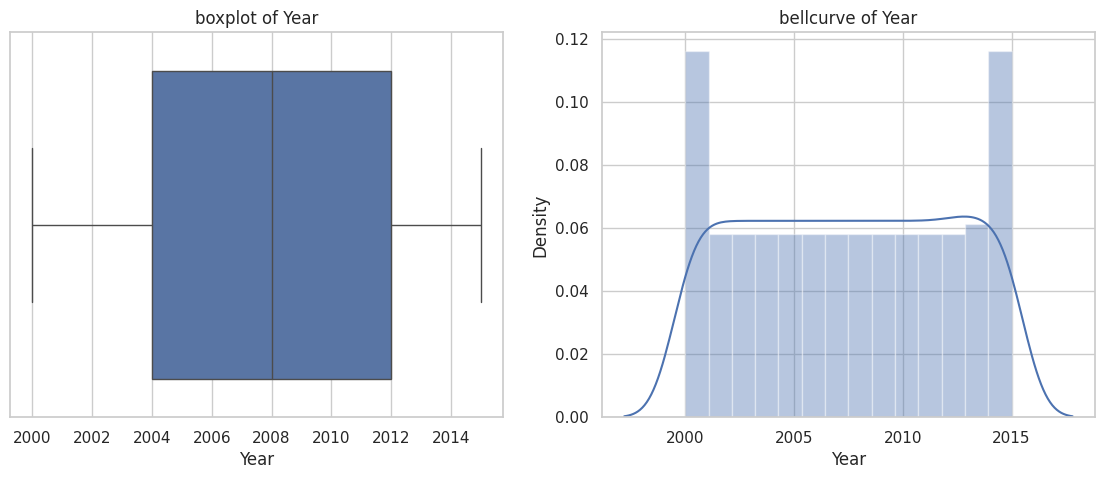

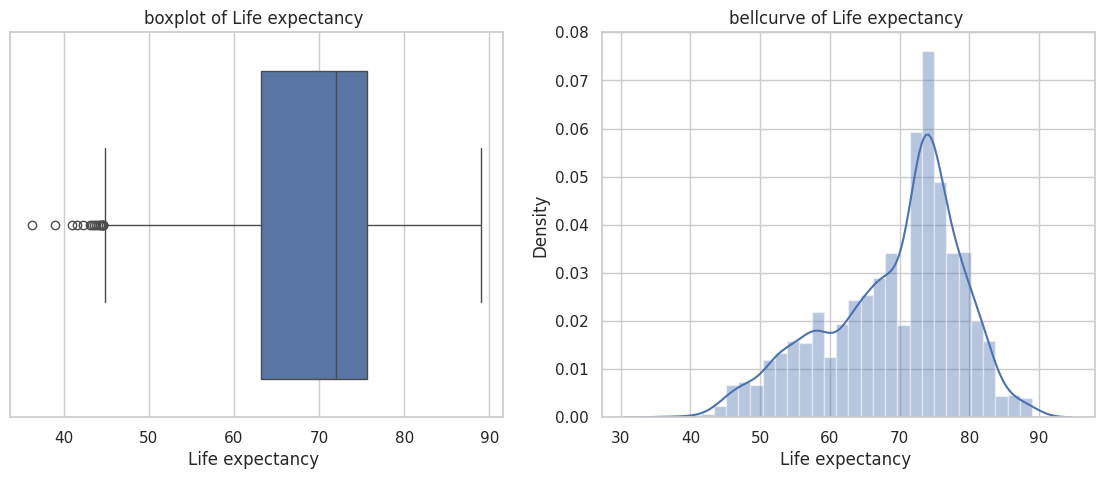

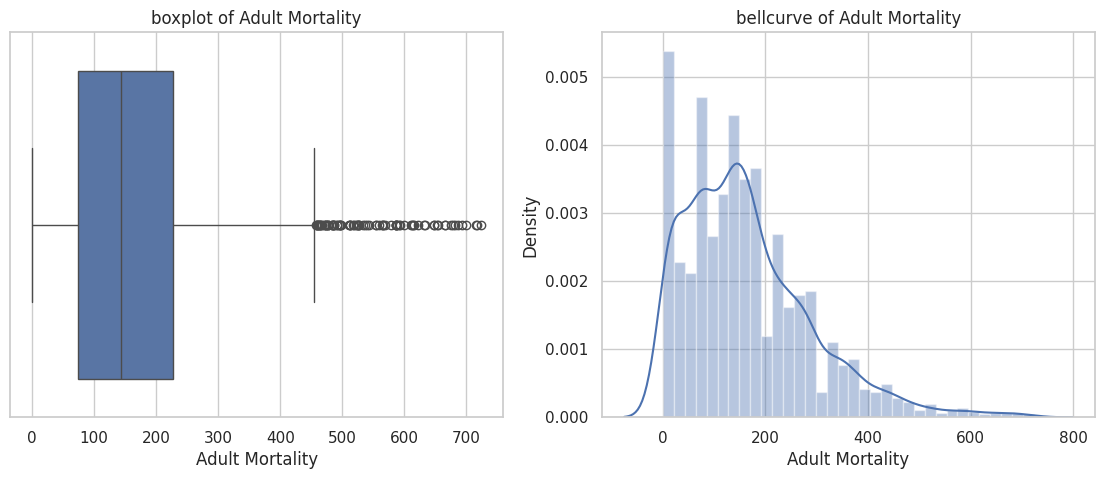

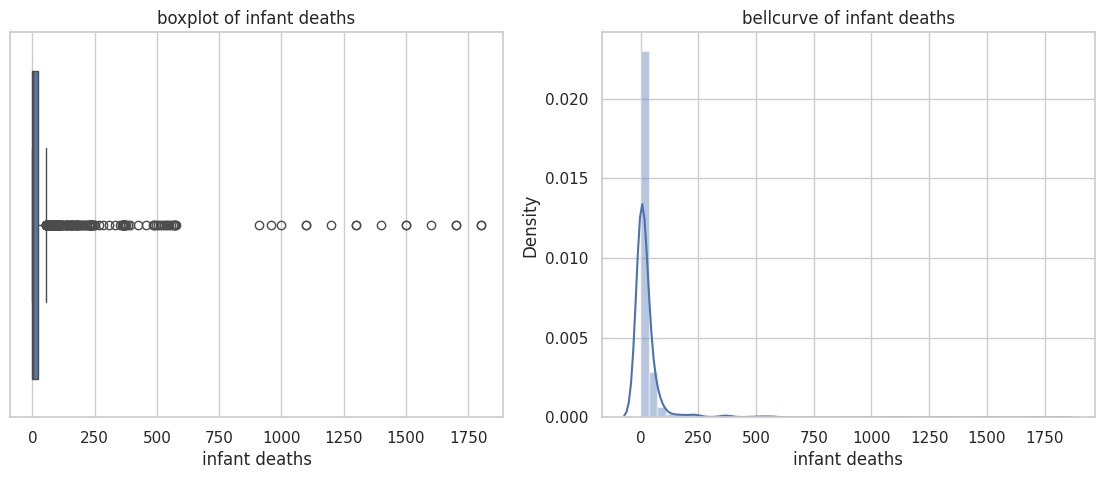

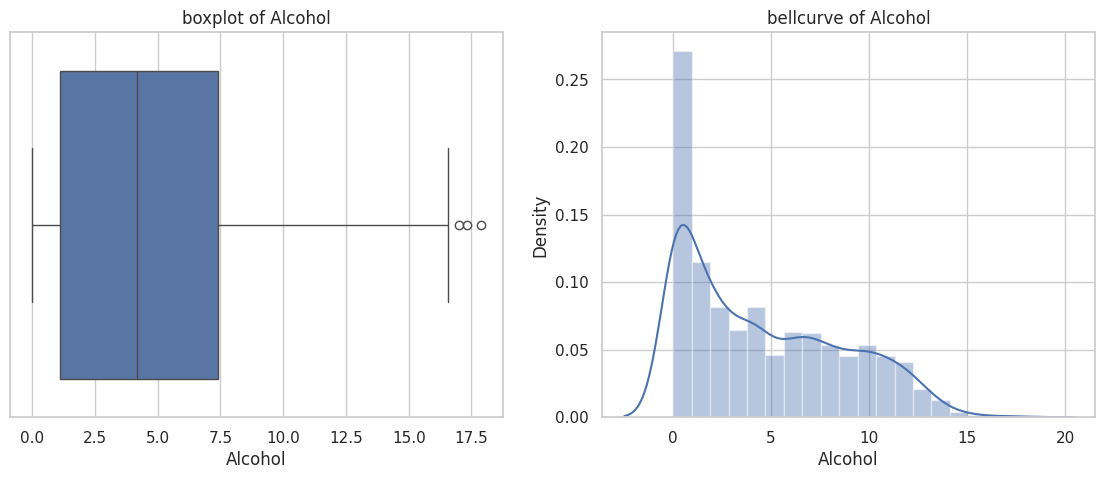

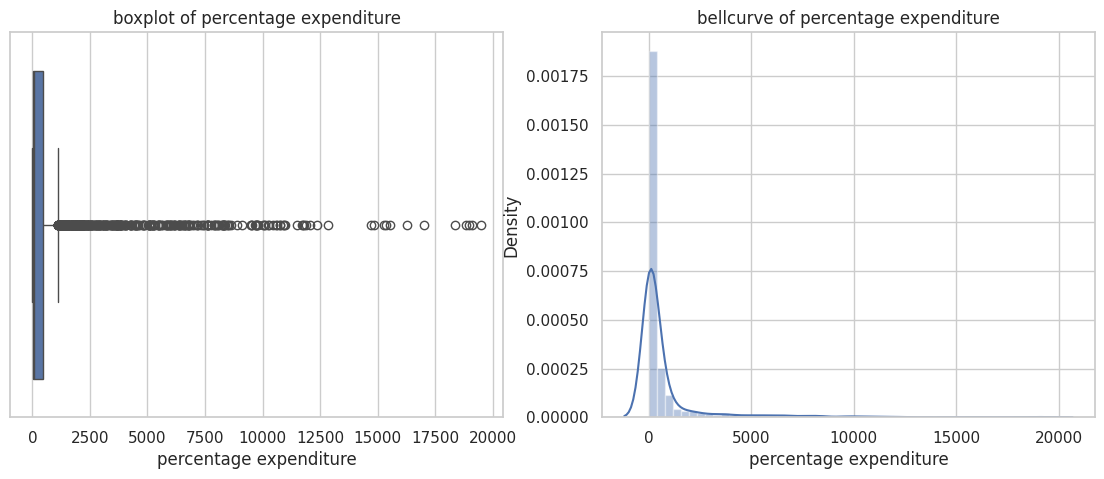

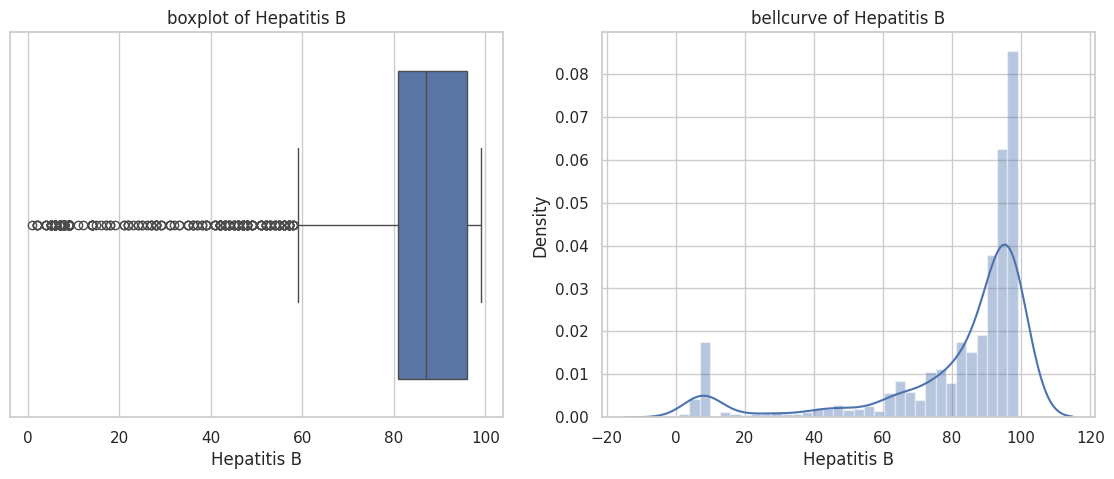

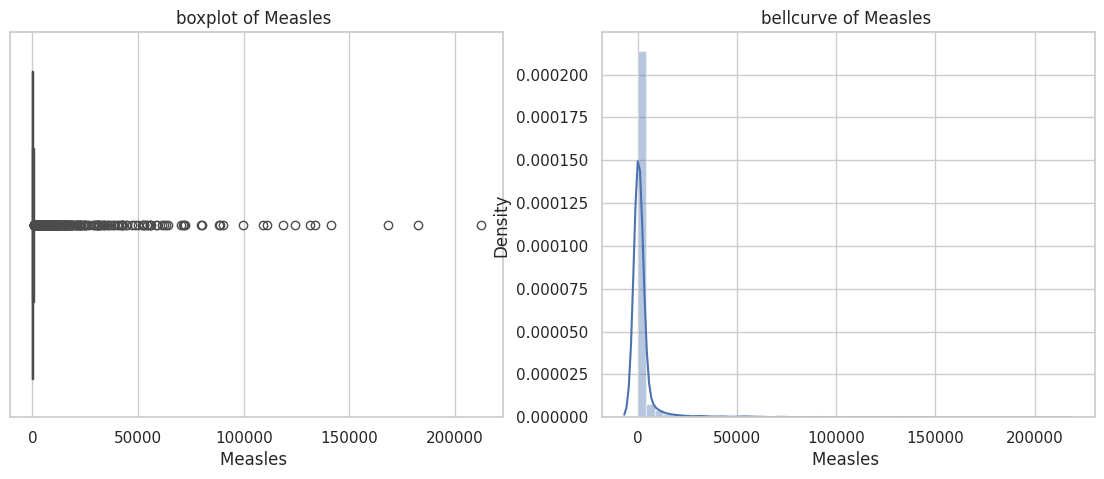

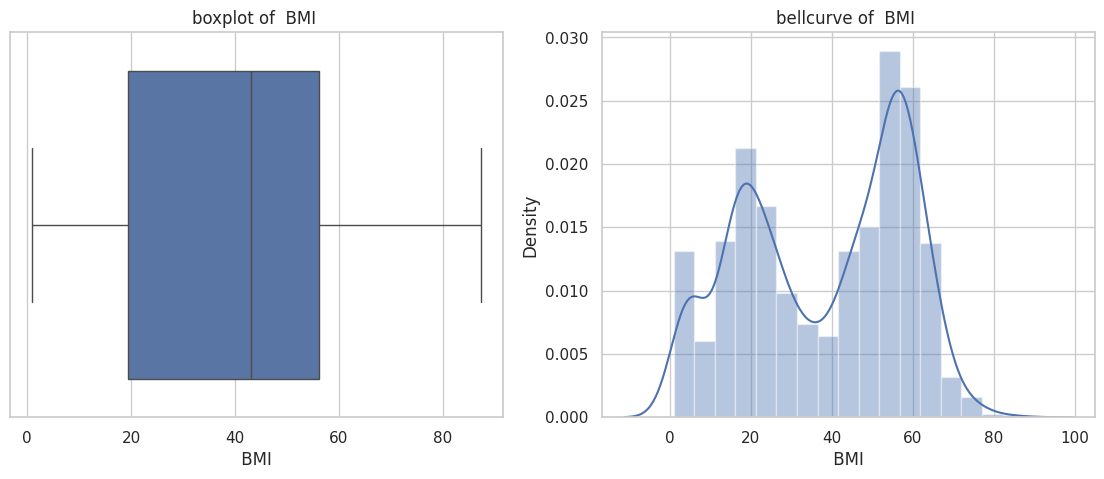

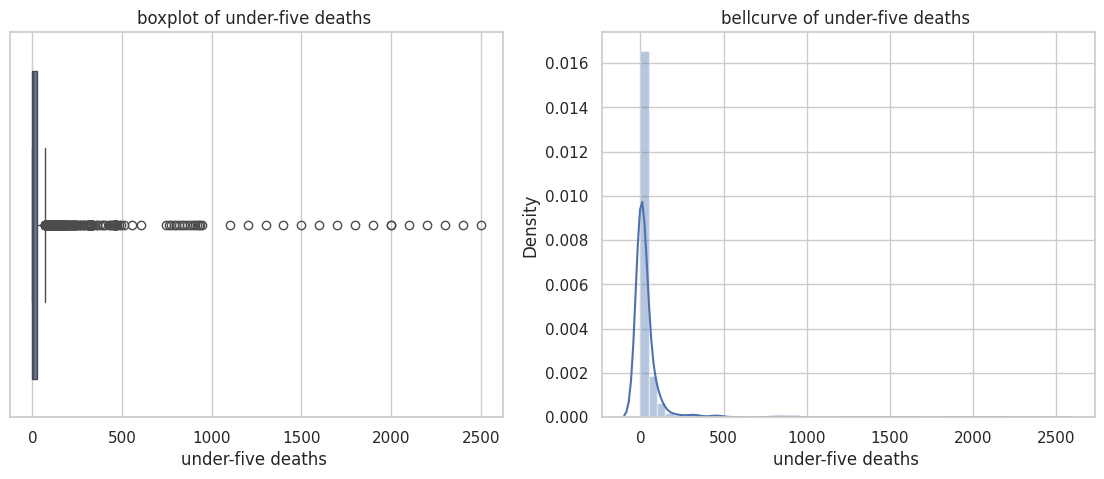

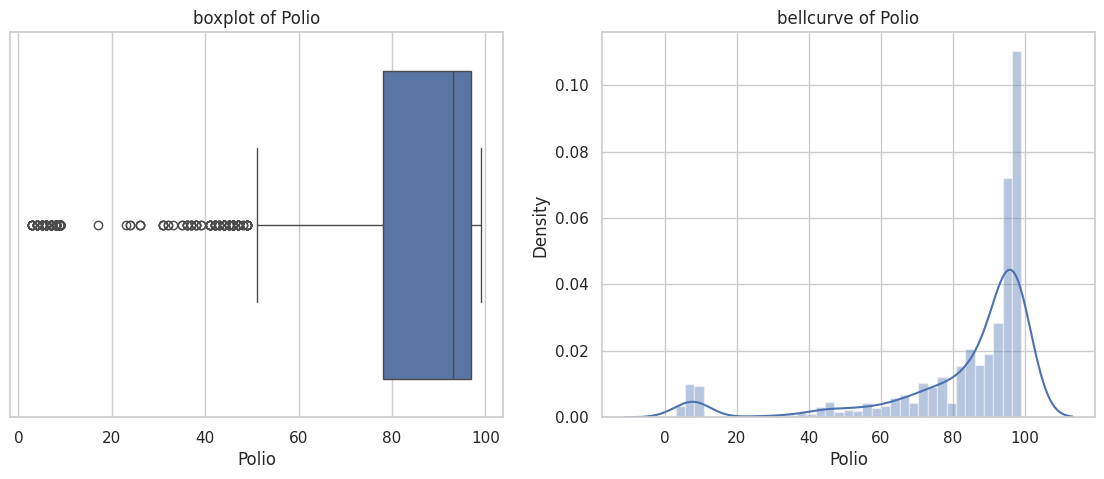

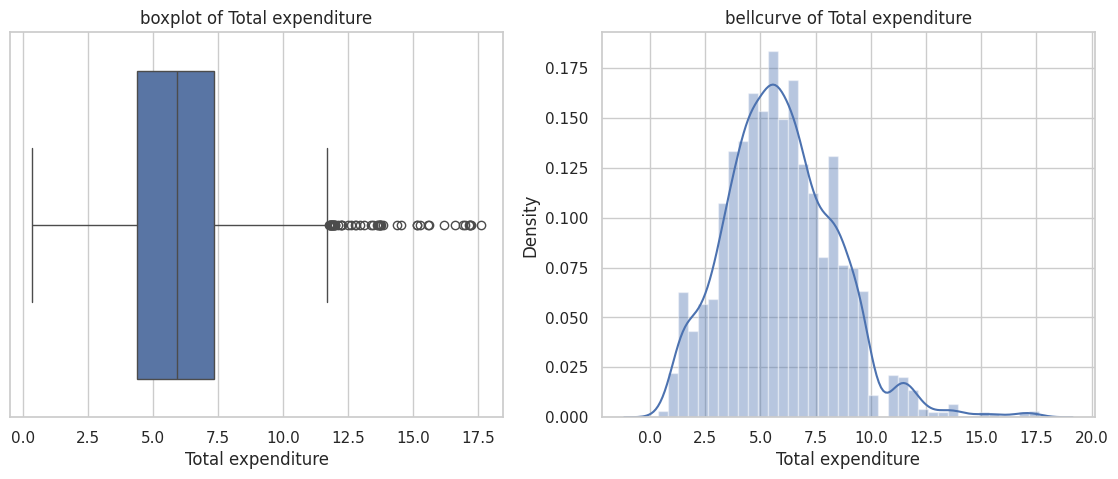

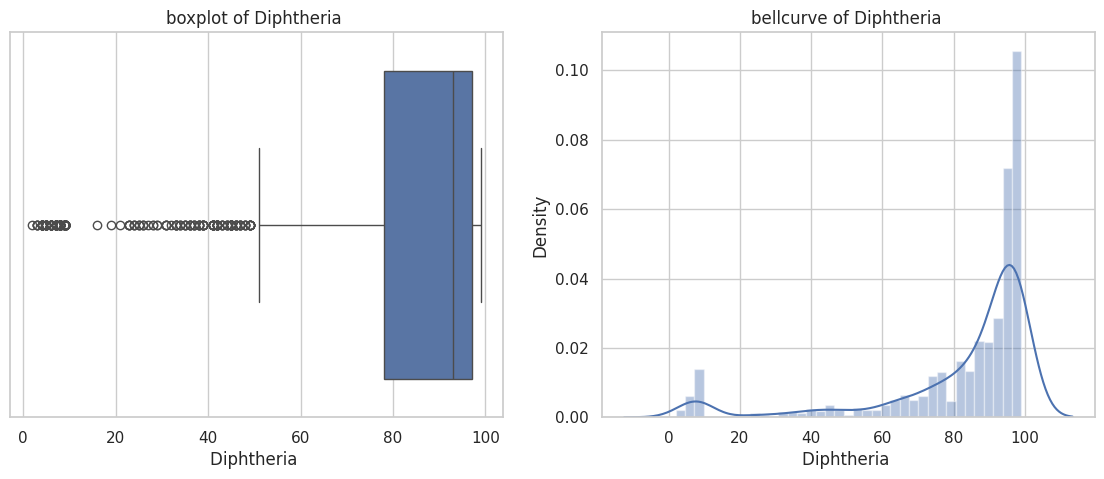

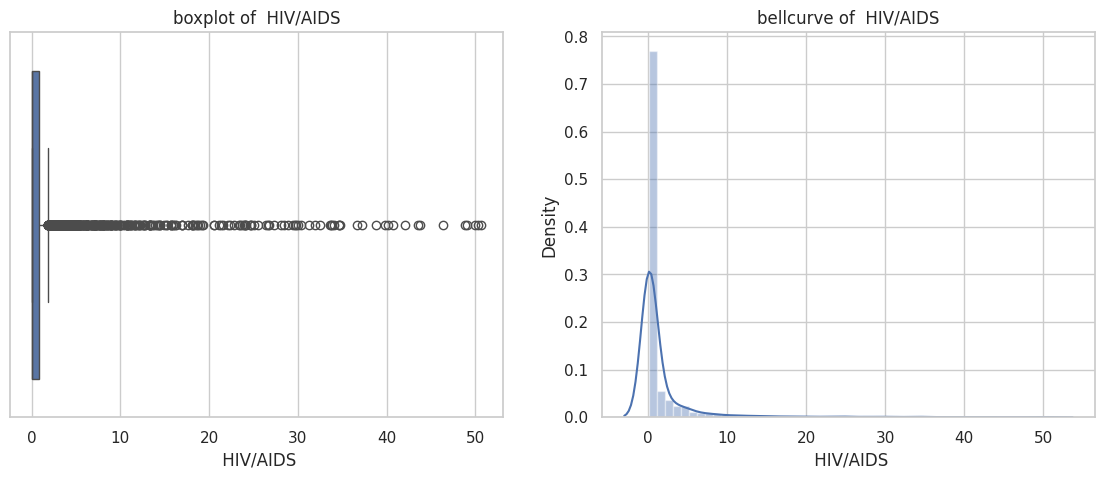

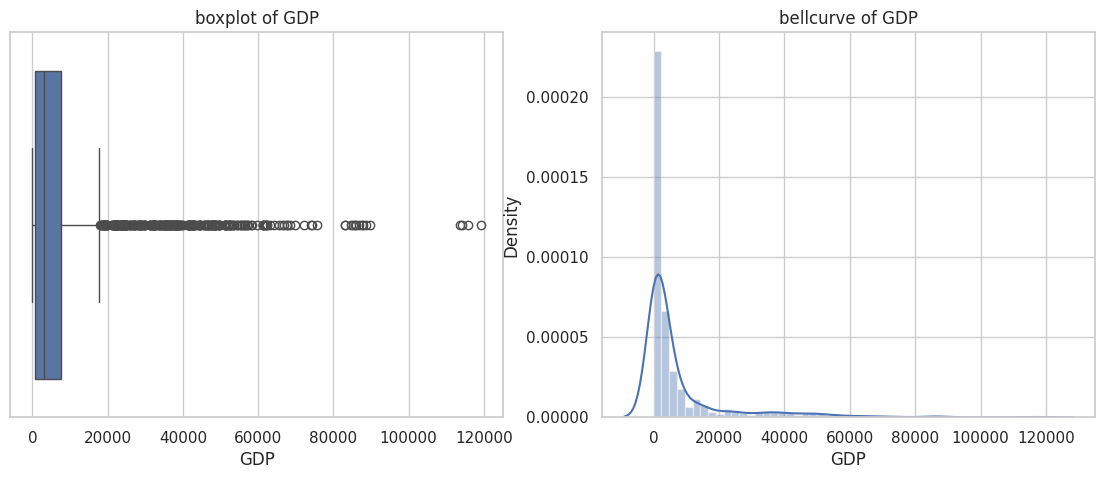

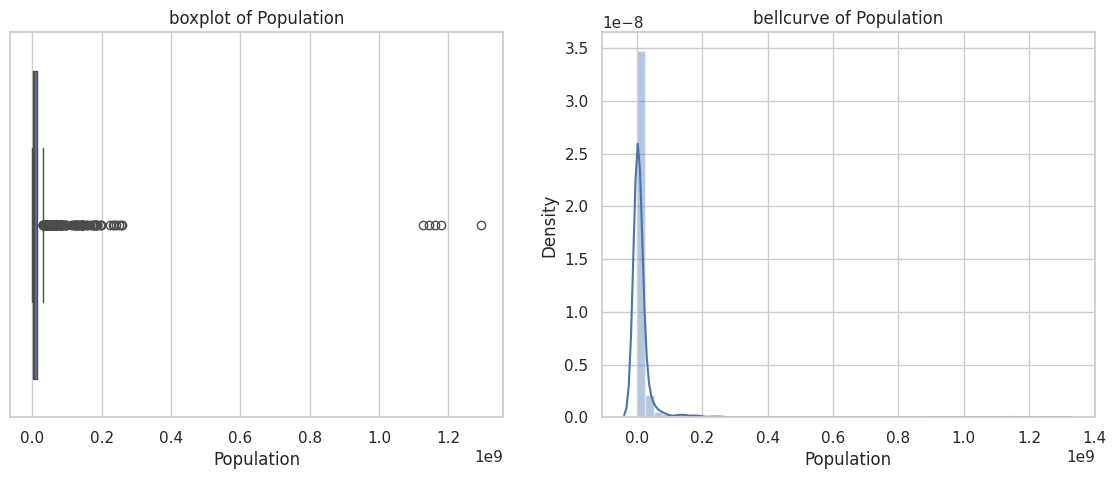

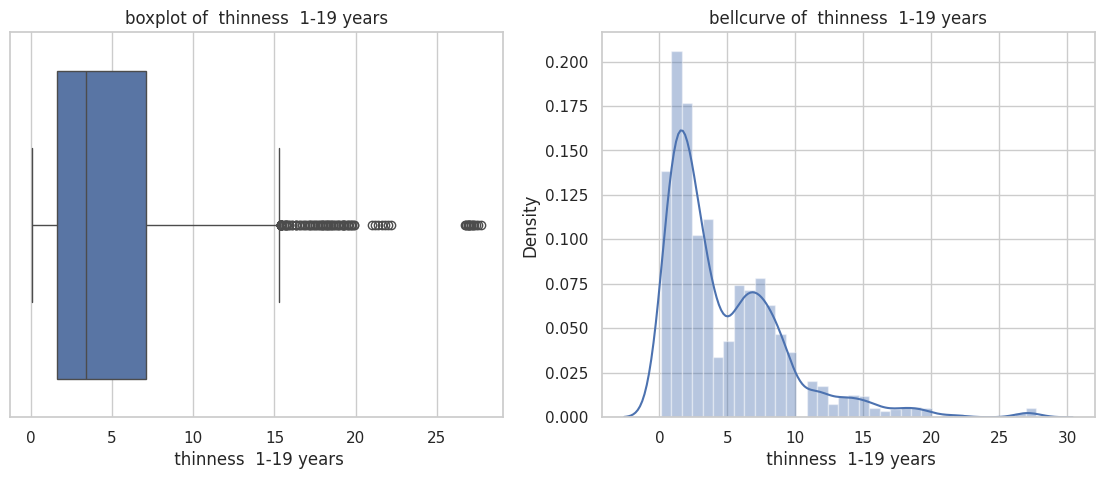

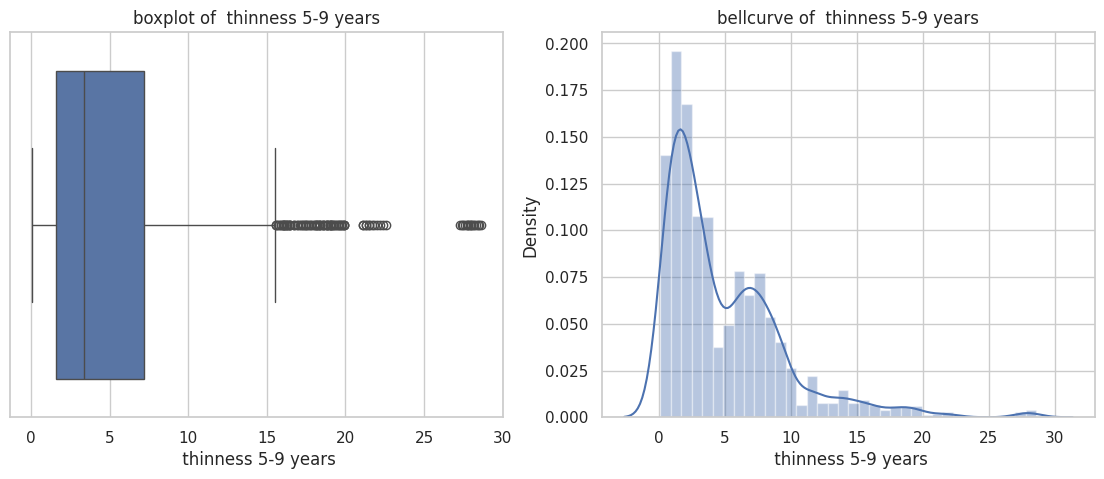

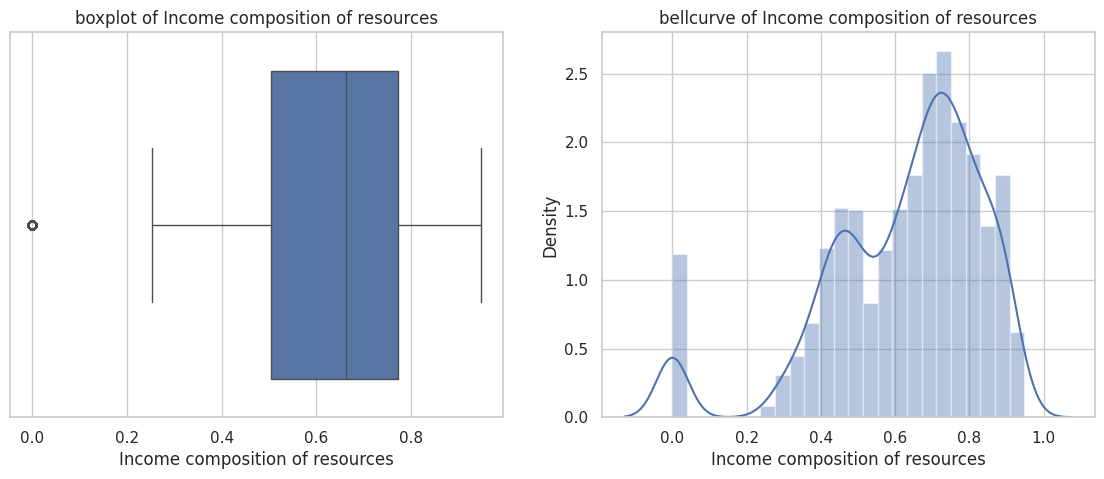

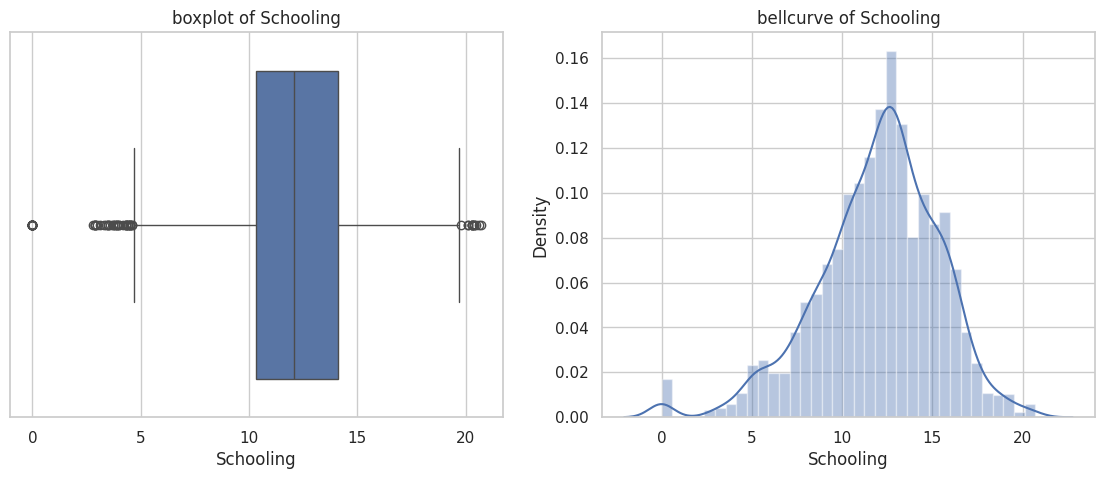

In [21]:
#checking for outliers
sns.set(style='whitegrid')

for col in numerical_data.columns:
  plt.figure(figsize=(14,5))

  plt.subplot(1,2,1)
  sns.boxplot(x=df[col])
  plt.title(f'boxplot of {col}')

  plt.subplot(1,2,2)
  sns.distplot(numerical_data[col])
  plt.title(f'bellcurve of {col}')
  plt.show()

In [10]:
#checking for null
df.isnull().sum()

,0
Country,0
Year,0
Status,0
Life expectancy,10
Adult Mortality,10
infant deaths,0
Alcohol,194
percentage expenditure,0
Hepatitis B,553
Measles,0


In [19]:
#imputing null values
df['Life expectancy ']=df['Life expectancy '].fillna(df['Life expectancy '].mean())
df['Adult Mortality']=df['Adult Mortality'].fillna(df['Adult Mortality'].mean())
df['Alcohol']=df['Alcohol'].fillna(df['Alcohol'].mean())
df['Hepatitis B']=df['Hepatitis B'].fillna(df['Hepatitis B'].mean())
df[' BMI ']=df[' BMI '].fillna(df[' BMI '].mean())
df['Polio']=df['Polio'].fillna(df['Polio'].mean())
df['Total expenditure']=df['Total expenditure'].fillna(df['Total expenditure'].mean())
df['Diphtheria ']=df['Diphtheria '].fillna(df['Diphtheria '].mean())
df[' thinness  1-19 years']=df[' thinness  1-19 years'].fillna(df[' thinness  1-19 years'].mean())
df[' thinness 5-9 years']=df[' thinness 5-9 years'].fillna(df[' thinness 5-9 years'].mean())
df['Income composition of resources']=df['Income composition of resources'].fillna(df['Income composition of resources'].mean())
df['Schooling']=df['Schooling'].fillna(df['Schooling'].mean())
df['GDP']=df['GDP'].fillna(df['GDP'].mean())
df['Population']=df['Population'].fillna(df['Population'].mean())



In [20]:
df.isnull().sum()

,0
Country,0
Year,0
Status,0
Life expectancy,0
Adult Mortality,0
infant deaths,0
Alcohol,0
percentage expenditure,0
Hepatitis B,0
Measles,0


In [27]:
#encoding using labelencoder
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Country']=le.fit_transform(df['Country'])
df['Status']=le.fit_transform(df['Status'])

In [28]:
#train test split
from sklearn.model_selection import train_test_split
x=df.drop('Life expectancy ',axis=1)
y=df['Life expectancy ']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=69)

#using robust scaler since there is a lot of outliers
from sklearn.preprocessing import RobustScaler
scaler=RobustScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)


In [30]:
#using linear regression algorithm
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.7996243580151039